**RNN vs LSTM on Airline Passenger Forecasting**

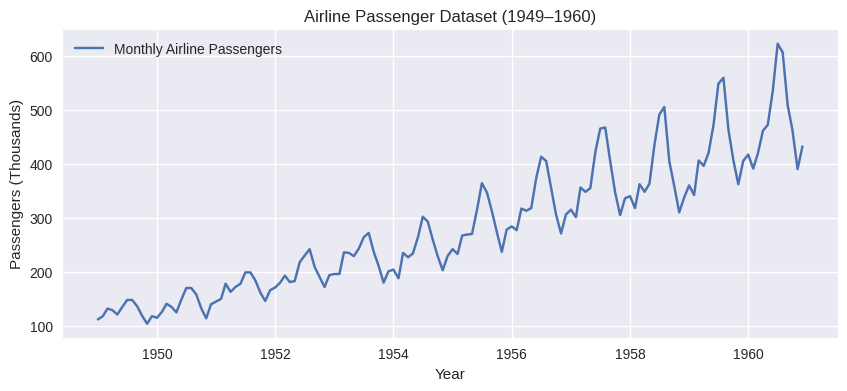

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

plt.style.use("seaborn-v0_8")

# Load dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

plt.figure(figsize=(10,4))
plt.plot(df, label="Monthly Airline Passengers")
plt.title("Airline Passenger Dataset (1949–1960)")
plt.xlabel("Year")
plt.ylabel("Passengers (Thousands)")
plt.legend()
plt.show()

data = df.values.astype(np.float32)


In [7]:
# Normalize between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(_______)

In [ ]:
# Create sequences
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12  # 1 year of data to predict next month
X, y = create_sequences(data)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

#80/20 split
train_size =
X_train, X_test =
y_train, y_test =


In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.rnn = nn.RNN(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

class SimpleLSTM(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


In [ ]:
def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch+1) % 20 == 0:
            print(f"{type(model).__name__} Epoch {epoch+1}/{epochs} | Loss: {loss.item():.6f}")
    return losses

#Define RNN and LSTM object
rnn_model =
lstm_model =

rnn_losses = train_model(rnn_model, ________, _______)
lstm_losses = train_model(lstm_model, ________, _______)


In [ ]:
#Fill the losses
plt.figure(figsize=(8,4))
plt.plot(______, label="RNN Loss", linestyle='--')
plt.plot(______, label="LSTM Loss")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


In [ ]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).numpy()

y_pred_rnn = predict(rnn_model, X_test)
y_pred_lstm = predict(lstm_model, X_test)

# Inverse scale
y_test_inv = scaler.inverse_transform(_____)
y_pred_rnn_inv = scaler.inverse_transform(________)
y_pred_lstm_inv = scaler.inverse_transform(_______)

plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='True', linewidth=2)
plt.plot(y_pred_rnn_inv, label='RNN Prediction', alpha=0.7)
plt.plot(y_pred_lstm_inv, label='LSTM Prediction', alpha=0.7)
plt.title("RNN vs LSTM Forecast — Airline Passengers")
plt.xlabel("Time step (months)")
plt.ylabel("Passengers (Thousands)")
plt.legend()
plt.show()
